<a href="https://colab.research.google.com/github/renegarcialuces/Analisis-de-Datos-Portafolio/blob/main/ED02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Variable objetivo:**
Chun = Si el cliente canceló el sevicio.
Esta es la variable a analizar

In [ ]:
# Importar herramientas de analisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import skew, describe

# **Carga de los datos**

In [ ]:
# Cargar documentos para analisis desde la pc
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Creación del DataFrame**

In [ ]:
filename = '/content/drive/MyDrive/Tablas/telecom_users.csv'
df = pd.read_csv(filename, index_col=0) #[index_col= 0] Elimina la columna (Unnamed: 0).

# **Conociendo el datset**

In [ ]:
# Qué columnas tiene el DataFrame?
df.columns

Index(['IDCliente', 'Genero', 'Aposentado', 'Casado', 'Dependentes',
       'MesesComoCliente', 'ServicoTelefone', 'MultiplasLinhas',
       'ServicoInternet', 'ServicoSegurancaOnline', 'ServicoBackupOnline',
       'ProtecaoEquipamento', 'ServicoSuporteTecnico', 'ServicoStreamingTV',
       'ServicoFilmes', 'TipoContrato', 'FaturaDigital', 'FormaPagamento',
       'ValorMensal', 'TotalGasto', 'Churn', 'Codigo'],
      dtype='object')

In [ ]:
# De qué tamaños es el set de datos?
df.shape

(5986, 22)

In [ ]:
# Tiene valores nulos o ausentes?
df.isna().sum()

,0
IDCliente,0
Genero,0
Aposentado,0
Casado,0
Dependentes,1
MesesComoCliente,0
ServicoTelefone,0
MultiplasLinhas,0
ServicoInternet,0
ServicoSegurancaOnline,0


In [ ]:
# Tipos de columnas?
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5986 entries, 1869 to 860
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IDCliente               5986 non-null   object 
 1   Genero                  5986 non-null   object 
 2   Aposentado              5986 non-null   int64  
 3   Casado                  5986 non-null   object 
 4   Dependentes             5985 non-null   object 
 5   MesesComoCliente        5986 non-null   int64  
 6   ServicoTelefone         5986 non-null   object 
 7   MultiplasLinhas         5986 non-null   object 
 8   ServicoInternet         5986 non-null   object 
 9   ServicoSegurancaOnline  5986 non-null   object 
 10  ServicoBackupOnline     5986 non-null   object 
 11  ProtecaoEquipamento     5986 non-null   object 
 12  ServicoSuporteTecnico   5986 non-null   object 
 13  ServicoStreamingTV      5986 non-null   object 
 14  ServicoFilmes           5986 non-null   obj

In [ ]:
# Distribución estadística de las columnas numericas
df.describe()

,Aposentado,MesesComoCliente,ValorMensal,Codigo
count,5986.000000,5986.000000,5986.000000,0.0
mean,0.161377,32.468760,64.802213,NaN
std,0.367909,24.516391,30.114702,NaN
min,0.000000,0.000000,18.250000,NaN
25%,0.000000,9.000000,35.650000,NaN
50%,0.000000,29.000000,70.400000,NaN
75%,0.000000,56.000000,89.900000,NaN
max,1.000000,72.000000,118.750000,NaN


In [ ]:
# Distribución estadística de las columnas categóricas
df.describe(exclude=['int', 'float'])

,IDCliente,Genero,Casado,Dependentes,ServicoTelefone,MultiplasLinhas,ServicoInternet,ServicoSegurancaOnline,ServicoBackupOnline,ProtecaoEquipamento,ServicoSuporteTecnico,ServicoStreamingTV,ServicoFilmes,TipoContrato,FaturaDigital,FormaPagamento,TotalGasto,Churn
count,5986,5986,5986,5985,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5985
unique,5986,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,5611,2
top,4795-UXVCJ,Masculino,Nao,Nao,Sim,Nao,Fibra,Nao,Nao,Nao,Nao,Nao,Nao,Mensal,Sim,BoletoEletronico,,Nao
freq,1,3050,3082,4195,5396,2848,2627,2982,2605,2640,2960,2389,2356,3269,3528,2006,10,4398


# **Limpieza y preparación de datos**

In [ ]:
# Ajuster tipo de categórico a numerico
df['TotalGasto'] = pd.to_numeric(df['TotalGasto'], errors='coerce')

In [ ]:
# Covertir columnas numericas a categoricos
df['Aposentado'] = df['Aposentado'].astype('category')
df['Aposentado'] = df['Aposentado'].map({1: 'Sim', 0: 'Não'})

In [ ]:
# Covertir columnas objectos a categoricos
for col in df.columns:
  if df[col].dtypes == 'O':
    df[col] = df[col].astype('category')

In [ ]:
# Borrando columnas vacia
df.dropna(axis=1, how='all', inplace=True)

In [ ]:
# Borras datos faltantes
df.dropna(how='any', inplace=True)

# **Tablas de frecuencia y gráficos**

<Figure size 800x500 with 0 Axes>

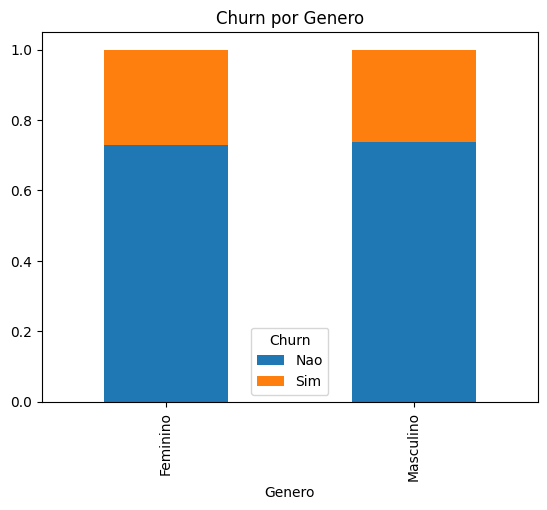

<Figure size 800x500 with 0 Axes>

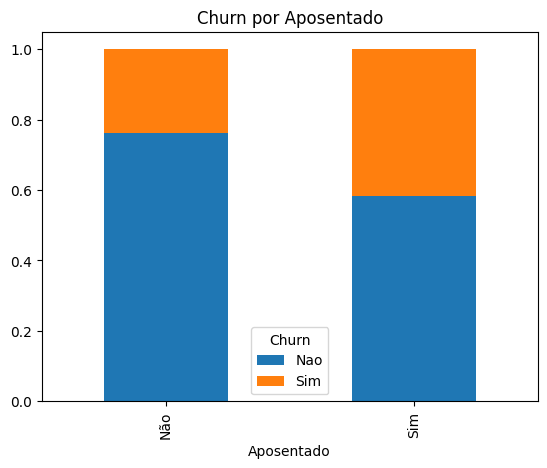

<Figure size 800x500 with 0 Axes>

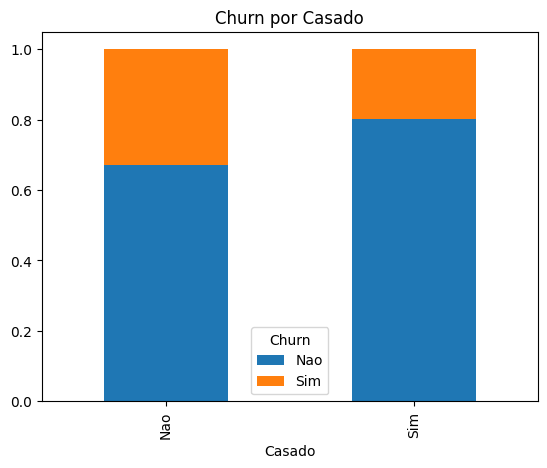

<Figure size 800x500 with 0 Axes>

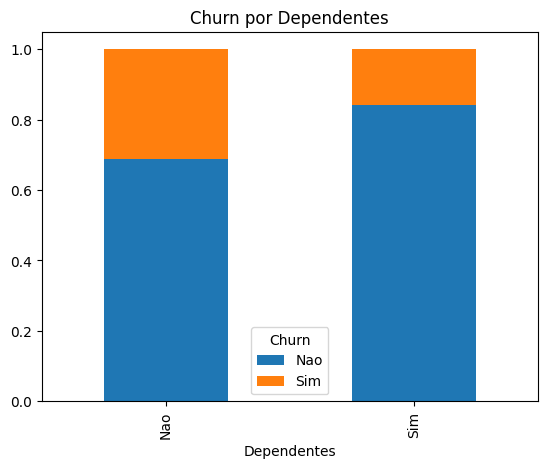

<Figure size 800x500 with 0 Axes>

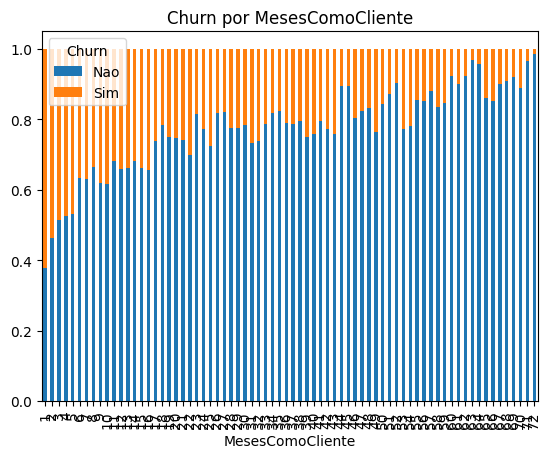

<Figure size 800x500 with 0 Axes>

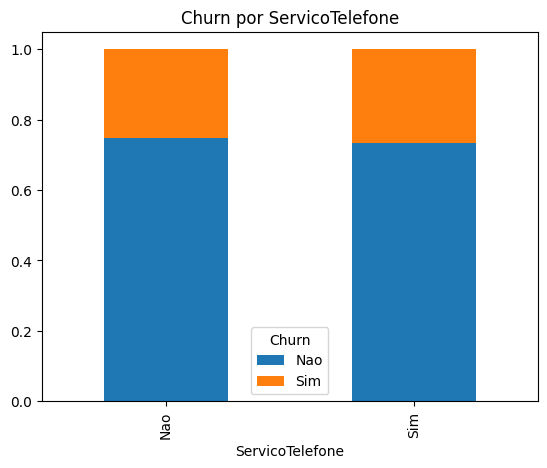

<Figure size 800x500 with 0 Axes>

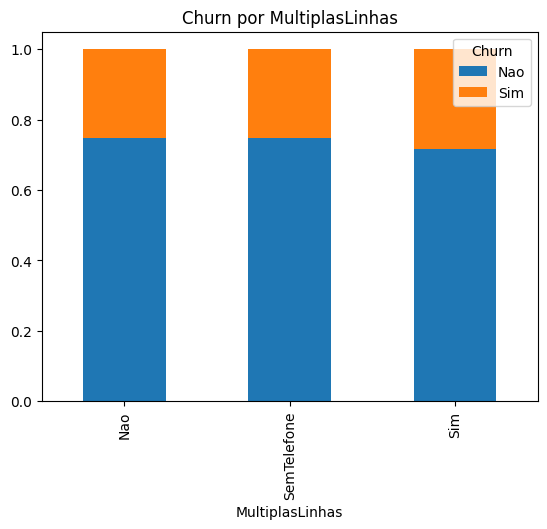

<Figure size 800x500 with 0 Axes>

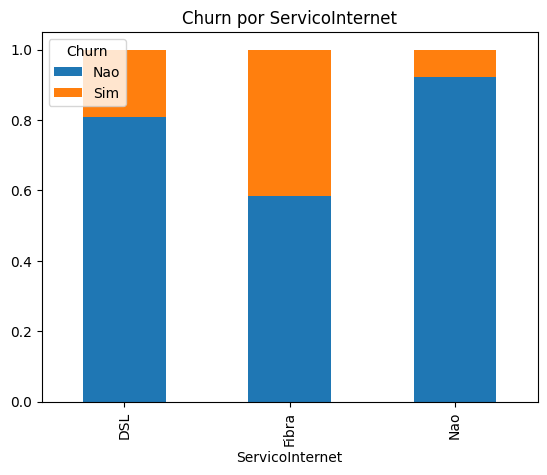

<Figure size 800x500 with 0 Axes>

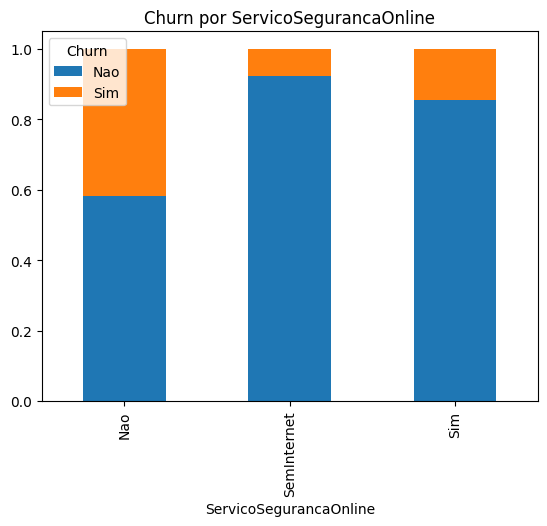

<Figure size 800x500 with 0 Axes>

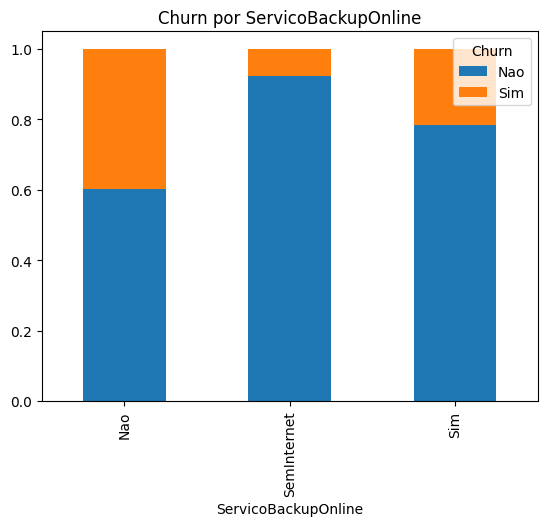

<Figure size 800x500 with 0 Axes>

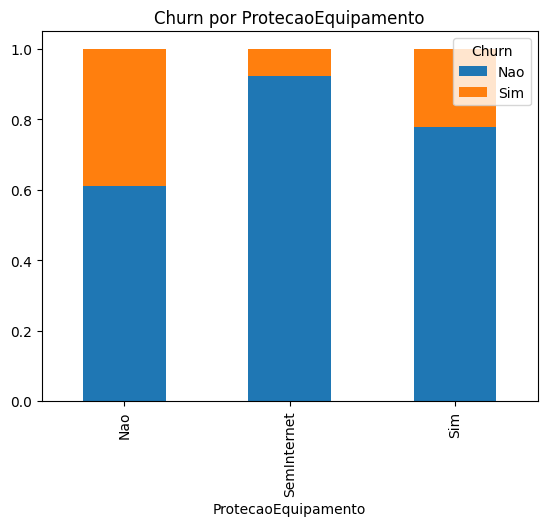

<Figure size 800x500 with 0 Axes>

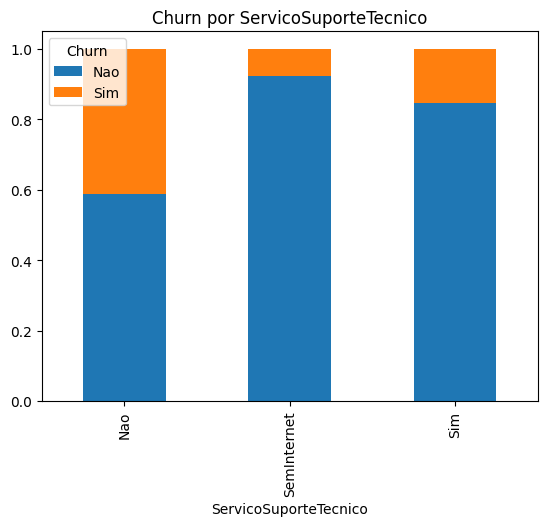

<Figure size 800x500 with 0 Axes>

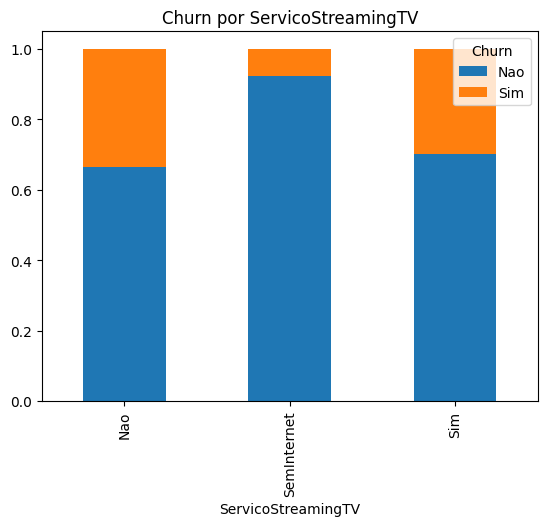

<Figure size 800x500 with 0 Axes>

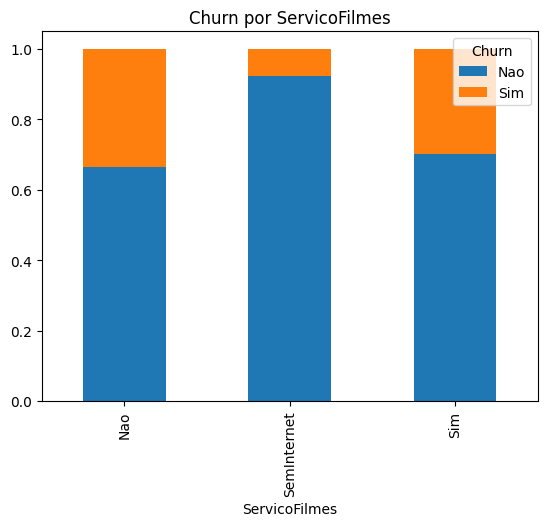

<Figure size 800x500 with 0 Axes>

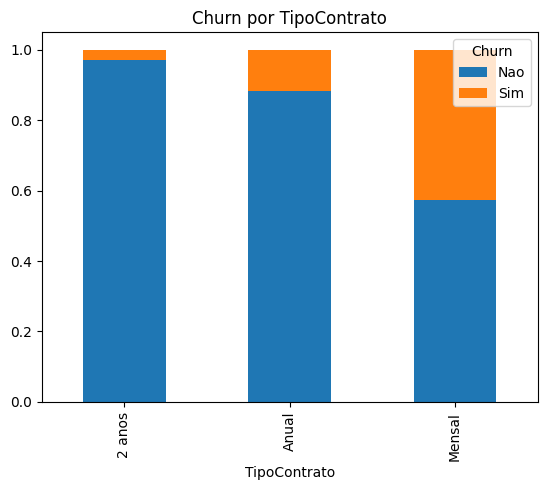

<Figure size 800x500 with 0 Axes>

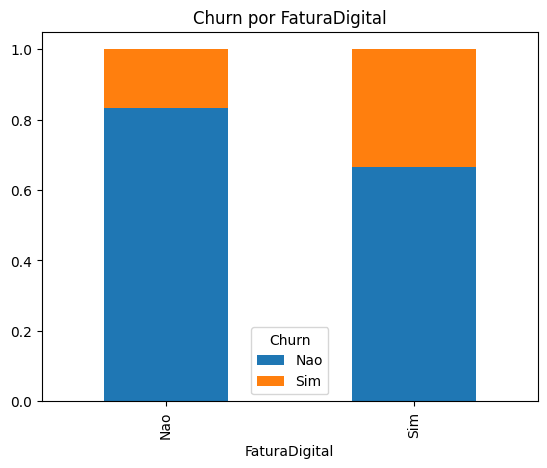

<Figure size 800x500 with 0 Axes>

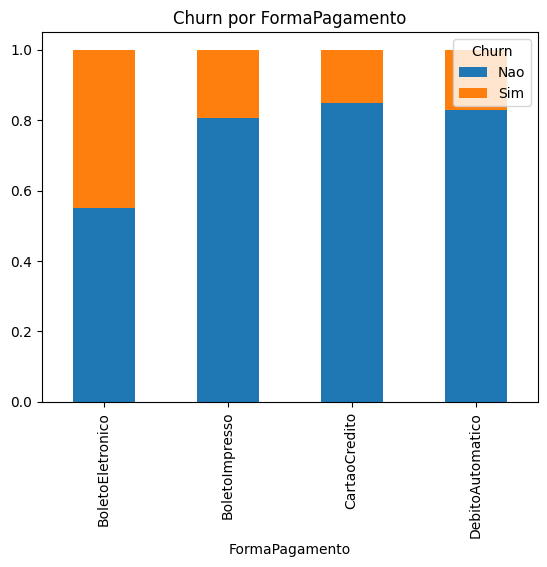

In [ ]:
for columna in df:
  if columna not in ['IDCliente', 'TotalGasto', 'Churn', 'Codigo', 'ValorMensal']:
    dfr = df['Churn'].groupby(df[columna], observed=True).value_counts(normalize=True).unstack()
    plt.figure(figsize=(8, 5)) # Adjust the figure size here
    dfr.plot.bar(stacked=True);
    plt.title(f'Churn por {columna}');
    plt.show();